In [1]:
import tensorflow as tf
ImportWarning
import pandas as pd
from pathlib import Path 


2025-03-09 09:10:58.322965: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-09 09:10:58.451539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741490758.492386   10107 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741490758.506041   10107 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-09 09:10:58.622089: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
path = Path('datasets/CTA_-_Ridership_-_Daily_Boarding_Totals.csv')
df = pd.read_csv(path,parse_dates=['service_date'])


In [3]:
df.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355
3,2001-01-04,W,870021,550011,1420032
4,2001-01-05,W,890426,557917,1448343


In [4]:
df.columns = ['date','day_type','bus','train','total']
df = df.sort_values('date').set_index('date')

In [5]:
df.head()

,day_type,bus,train,total
date,,,,
2001-01-01,U,297192,126455,423647
2001-01-02,W,780827,501952,1282779
2001-01-03,W,824923,536432,1361355
2001-01-04,W,870021,550011,1420032
2001-01-05,W,890426,557917,1448343


In [6]:
df.drop('total',axis = 'columns',inplace = True)#no need for total , its just bus+ rail
df.drop_duplicates() #remove duplicated months (2022-10 and 2014-07)

,day_type,bus,train
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830


In [7]:
df.tail()

,day_type,bus,train
date,,,
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830
2021-11-29,W,421322,276090
2021-11-30,W,450230,302349


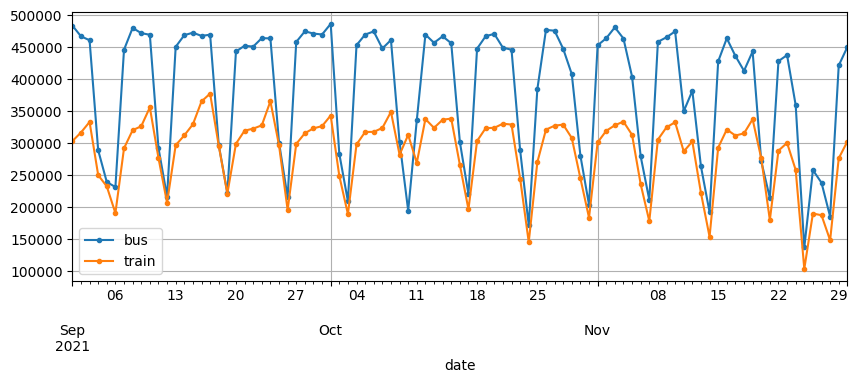

In [8]:
import matplotlib.pyplot as plt

df['2019-09':'2019-11'].plot(grid=True,marker = '.',figsize = (10,3.5))
plt.show()

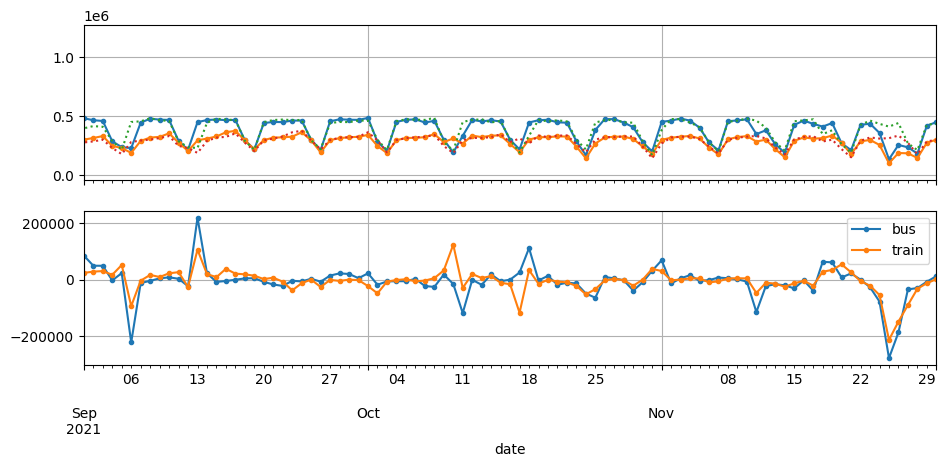

In [9]:
diff_7 = df[['bus','train']].diff(7)['2019-09':'2019-11']

fig,axs = plt.subplots(2,1,sharex=True,figsize=(11,5))
df.plot(ax=axs[0],legend = False,marker='.')#original time series


df.shift(7).plot(ax=axs[0],grid=True,legend=False,linestyle=':') #lagged on the top
diff_7.plot(ax=axs[1],grid=True,marker='.') #7-day difference time series
plt.show()

In [10]:
list (df.loc['2019-11-24':'2019-11-27']['day_type'])

['W', 'U', 'W', 'A']

In [11]:
diff_7.abs().mean()

bus      30279.879121
train    25270.835165
dtype: float64

In [12]:
targets = df[['bus','train']]['2019-09':'2019-11']

(diff_7/targets).abs().mean()


bus      0.103901
train    0.116000
dtype: float64

In [13]:
period = df['2001-01-01':'2019-11-']
period.tail()

,day_type,bus,train
date,,,
2019-11-18,W,807951,731335
2019-11-19,W,822152,755257
2019-11-20,W,839934,756096
2019-11-21,W,790016,752762
2019-11-22,W,817445,782838


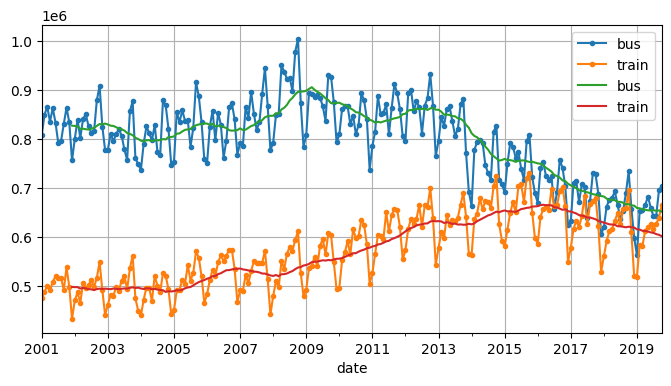

In [16]:
# Define the start and end dates for the period
start_date = '2001-01-01'
end_date = '2019-11-22'

# Select only numeric columns for resampling and mean calculation
df_numeric = df.select_dtypes(include='number')

# Resample the data to monthly frequency and compute the mean
df_monthly = df_numeric.resample('ME').mean()

# Filter the data for the specified period using .loc[]
df_monthly_period = df_monthly.loc[start_date:end_date]

# Compute the 12-month rolling average
rolling_average_12_months = df_monthly_period.rolling(window=12).mean()

# Plot the data
fig, ax = plt.subplots(figsize=(8, 4))
df_monthly_period.plot(ax=ax, marker='.', label='Monthly Mean')
rolling_average_12_months.plot(ax=ax, grid=True, label='12-Month Rolling Mean', legend=True)

plt.legend()
plt.show() 

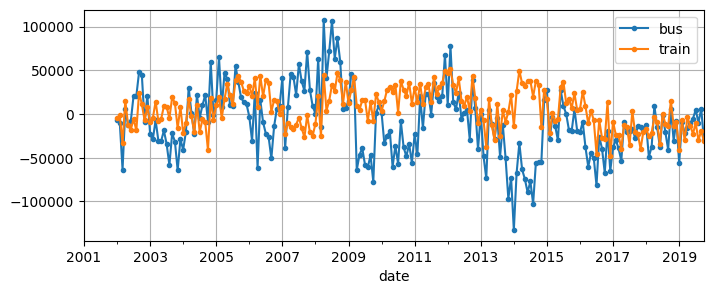

In [17]:
df_monthly.diff(12)[start_date:end_date].plot(grid=True,marker='.',figsize =(8,3))
plt.show()